# Compare Real and Synthetic CMB Characteristic Distributions

In [1]:
%pip install pandas openpyxl matplotlib


[notice] A new release of pip is available: 24.3.1 -> 26.2.1
[notice] To update, run: python3.10 -m pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


## Composite Graph of Lesion burden, lesion volume, Elongation Ratio and Signal characteristics

Real elongation: plotting 682/687 lesions (5 excluded)
Synthetic elongation: plotting 348/352 lesions (4 excluded)


/var/folders/6y/6jqs7by52817kptbghm_vxh40000gn/T/ipykernel_3609/934901125.py:504: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(
/var/folders/6y/6jqs7by52817kptbghm_vxh40000gn/T/ipykernel_3609/934901125.py:504: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(


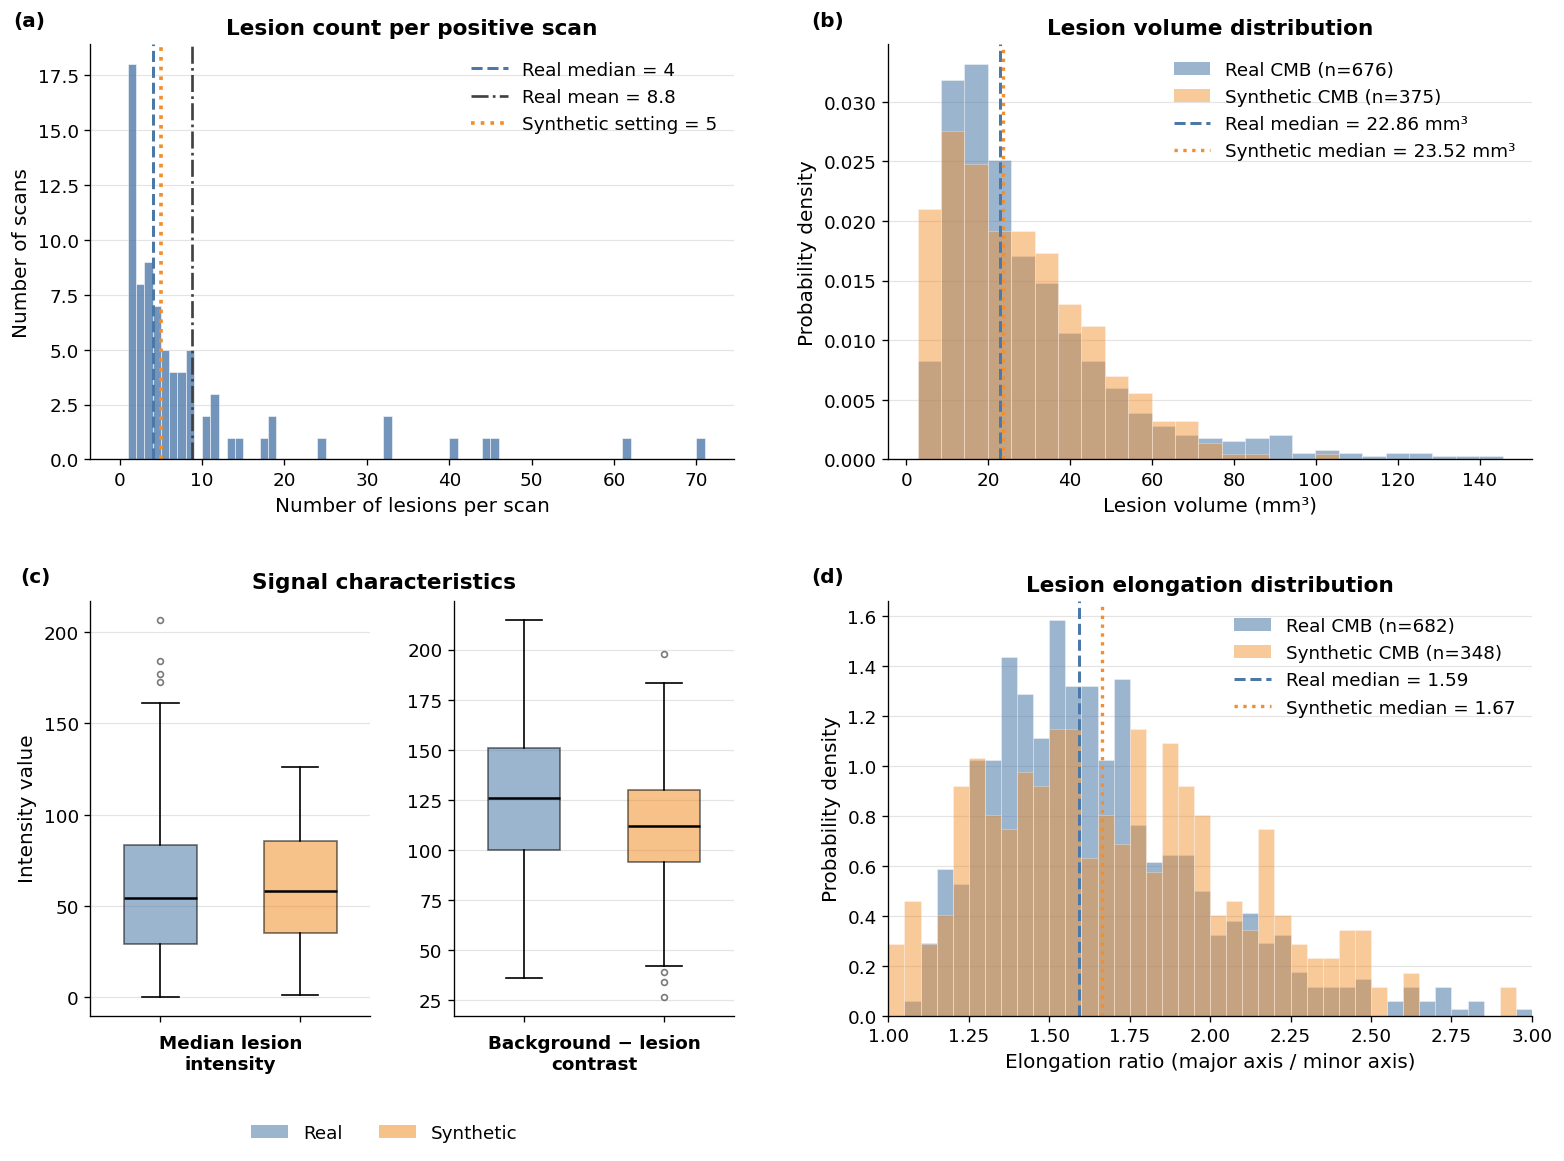

Saved PNG: ./real_vs_synthetic_characteristics_composite.png
Saved PDF: ./real_vs_synthetic_characteristics_composite.pdf


In [9]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec, GridSpecFromSubplotSpec
from matplotlib.patches import Patch
from matplotlib.lines import Line2D


# ----------------------------------------------------------------
# Paths
# ----------------------------------------------------------------
real_shape_csv = Path(
    "./stats/Realmicrobleed_shape_stats.csv"
)

synth_shape_csv = Path(
    "./stats/Synthmicrobleed_shape_stats.csv"
)

real_profile_csv = Path(
    "./stats/Realmicrobleed_profile_stats.csv"
)

synth_profile_csv = Path(
    "./stats/Synthmicrobleed_profile_stats.csv"
)

output_png = "./real_vs_synthetic_characteristics_composite.png"
output_pdf = "./real_vs_synthetic_characteristics_composite.pdf"


# ----------------------------------------------------------------
# Publication style
# ----------------------------------------------------------------
REAL_COLOR = "#4C78A8"
SYNTH_COLOR = "#F28E2B"
GRID_COLOR = "#D9D9D9"

plt.rcParams.update({
    "font.family": "DejaVu Sans",
    "font.size": 11,
    "axes.titlesize": 13,
    "axes.titleweight": "semibold",
    "axes.labelsize": 12,
    "xtick.labelsize": 11,
    "ytick.labelsize": 11,
    "legend.fontsize": 11,
    "axes.linewidth": 0.8,
    "xtick.major.width": 0.8,
    "ytick.major.width": 0.8,
    "figure.dpi": 120,
    "savefig.dpi": 600,
    "pdf.fonttype": 42,
    "ps.fonttype": 42,
})


def clean_numeric(series):
    values = pd.to_numeric(series, errors="coerce")
    return values.replace([np.inf, -np.inf], np.nan).dropna()


def style_axis(ax):
    ax.grid(axis="y", color=GRID_COLOR, linewidth=0.7, alpha=0.7)
    ax.set_axisbelow(True)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)


def panel_label(ax, label, x=-0.12, y=1.08):
    ax.text(
        x, y, label,
        transform=ax.transAxes,
        fontsize=12,
        fontweight="bold",
        va="top",
        ha="left",
    )


# ----------------------------------------------------------------
# Load data
# ----------------------------------------------------------------
for path in [
    real_shape_csv,
    synth_shape_csv,
    real_profile_csv,
    synth_profile_csv,
]:
    if not path.exists():
        raise FileNotFoundError(f"CSV not found: {path}")

real_shape = pd.read_csv(real_shape_csv)
synth_shape = pd.read_csv(synth_shape_csv)
real_profile = pd.read_csv(real_profile_csv)
synth_profile = pd.read_csv(synth_profile_csv)

for df in [real_shape, synth_shape, real_profile, synth_profile]:
    df.columns = df.columns.str.strip()


# ----------------------------------------------------------------
# Prepare lesion count data
# ----------------------------------------------------------------
case_column = "case_id"

if case_column not in real_profile.columns:
    raise KeyError(
        f"'{case_column}' not found in real profile CSV. "
        f"Available columns: {real_profile.columns.tolist()}"
    )

lesions_per_scan = real_profile.groupby(case_column).size()

count_mean = lesions_per_scan.mean()
count_median = lesions_per_scan.median()

synthetic_count = 5


# ----------------------------------------------------------------
# Prepare volume data
# ----------------------------------------------------------------
volume_column = "volume_mm3"

if volume_column not in real_shape.columns or volume_column not in synth_shape.columns:
    raise KeyError(f"Required volume column not found: {volume_column}")

real_volume_all = clean_numeric(real_shape[volume_column])
synth_volume_all = clean_numeric(synth_shape[volume_column])

real_volume_all = real_volume_all[real_volume_all > 0]
synth_volume_all = synth_volume_all[synth_volume_all > 0]

combined_volume_all = pd.concat(
    [real_volume_all, synth_volume_all],
    ignore_index=True,
)

# Remove only the extreme upper tail for visualization
upper_cutoff = combined_volume_all.quantile(0.99)

real_volume = real_volume_all[
    real_volume_all <= upper_cutoff
]
synth_volume = synth_volume_all[
    synth_volume_all <= upper_cutoff
]

combined_volume = pd.concat(
    [real_volume, synth_volume],
    ignore_index=True,
)

volume_bins = np.linspace(
    combined_volume.min(),
    combined_volume.max(),
    26,
)


# ----------------------------------------------------------------
# Prepare intensity data
# ----------------------------------------------------------------
intensity_metrics = [
    (
        "lesion_intensity_median",
        "Median lesion\nintensity"
    ),
    (
        "dark_contrast_abs_bg_minus_lesion",
        "Background − lesion\ncontrast"
    ),
]

intensity_data = {}

for column, title in intensity_metrics:

    if (
        column not in real_profile.columns
        or column not in synth_profile.columns
    ):
        raise KeyError(
            f"Required intensity column not found: {column}"
        )

    intensity_data[column] = (
        clean_numeric(real_profile[column]),
        clean_numeric(synth_profile[column]),
        title,
    )


# ----------------------------------------------------------------
# Prepare elongation-ratio data
# ----------------------------------------------------------------
elongation_column = "elongation_major_minor"

if (
    elongation_column not in real_shape.columns
    or elongation_column not in synth_shape.columns
):
    raise KeyError(
        f"Required elongation column not found: {elongation_column}"
    )

# Full valid distributions
real_elongation_all = clean_numeric(
    real_shape[elongation_column]
)

synth_elongation_all = clean_numeric(
    synth_shape[elongation_column]
)

# Elongation should be >= 1 by definition
real_elongation_all = real_elongation_all[
    real_elongation_all >= 1.0
]

synth_elongation_all = synth_elongation_all[
    synth_elongation_all >= 1.0
]


# Visualization range
# Elongation = 1 means perfectly spherical.
plot_min = 1.0
plot_max = 3.0
elongation_bin_width = 0.05

real_elongation = real_elongation_all[
    (real_elongation_all >= plot_min)
    & (real_elongation_all <= plot_max)
].copy()

synth_elongation = synth_elongation_all[
    (synth_elongation_all >= plot_min)
    & (synth_elongation_all <= plot_max)
].copy()


print(
    f"Real elongation: plotting "
    f"{len(real_elongation)}/{len(real_elongation_all)} lesions "
    f"({len(real_elongation_all) - len(real_elongation)} excluded)"
)

print(
    f"Synthetic elongation: plotting "
    f"{len(synth_elongation)}/{len(synth_elongation_all)} lesions "
    f"({len(synth_elongation_all) - len(synth_elongation)} excluded)"
)


# Medians are calculated using FULL valid distributions,
# not only lesions displayed between 1 and 3.
real_elongation_median = real_elongation_all.median()
synth_elongation_median = synth_elongation_all.median()


elongation_bins = np.arange(
    plot_min,
    plot_max + elongation_bin_width,
    elongation_bin_width,
)


# ----------------------------------------------------------------
# Build 2 × 2 composite figure
# ----------------------------------------------------------------
fig = plt.figure(
    figsize=(13.2, 9.2)
)

outer = GridSpec(
    2, 2,
    figure=fig,
    left=0.075,
    right=0.985,
    bottom=0.085,
    top=0.965,
    wspace=0.24,
    hspace=0.34,
)


# ================================================================
# (a) Lesion count per scan
# ================================================================
ax_a = fig.add_subplot(
    outer[0, 0]
)

maximum_count = int(
    lesions_per_scan.max()
)

count_bins = np.arange(
    0,
    maximum_count + 2
)

ax_a.hist(
    lesions_per_scan,
    bins=count_bins,
    color=REAL_COLOR,
    alpha=0.78,
    edgecolor="white",
    linewidth=0.4,
)

ax_a.axvline(
    count_median,
    color=REAL_COLOR,
    linestyle="--",
    linewidth=1.8,
)

ax_a.axvline(
    count_mean,
    color="0.25",
    linestyle="-.",
    linewidth=1.6,
)

ax_a.axvline(
    synthetic_count,
    color=SYNTH_COLOR,
    linestyle=":",
    linewidth=2.2,
)

ax_a.set_title(
    "Lesion count per positive scan"
)

ax_a.set_xlabel(
    "Number of lesions per scan"
)

ax_a.set_ylabel(
    "Number of scans"
)

ax_a.legend(
    handles=[
        Line2D(
            [0], [0],
            color=REAL_COLOR,
            linestyle="--",
            linewidth=1.8,
            label=f"Real median = {count_median:g}",
        ),
        Line2D(
            [0], [0],
            color="0.25",
            linestyle="-.",
            linewidth=1.6,
            label=f"Real mean = {count_mean:.1f}",
        ),
        Line2D(
            [0], [0],
            color=SYNTH_COLOR,
            linestyle=":",
            linewidth=2.2,
            label=f"Synthetic setting = {synthetic_count}",
        ),
    ],
    frameon=False,
    loc="upper right",
)

style_axis(ax_a)
panel_label(ax_a, "(a)")


# ================================================================
# (b) Lesion volume distribution
# ================================================================
ax_b = fig.add_subplot(
    outer[0, 1]
)

ax_b.hist(
    real_volume,
    bins=volume_bins,
    density=True,
    color=REAL_COLOR,
    alpha=0.55,
    edgecolor="white",
    linewidth=0.35,
)

ax_b.hist(
    synth_volume,
    bins=volume_bins,
    density=True,
    color=SYNTH_COLOR,
    alpha=0.48,
    edgecolor="white",
    linewidth=0.35,
)

real_volume_median = real_volume_all.median()
synth_volume_median = synth_volume_all.median()

ax_b.axvline(
    real_volume_median,
    color=REAL_COLOR,
    linestyle="--",
    linewidth=1.8,
)

ax_b.axvline(
    synth_volume_median,
    color=SYNTH_COLOR,
    linestyle=":",
    linewidth=2.0,
)

ax_b.set_title(
    "Lesion volume distribution"
)

ax_b.set_xlabel(
    "Lesion volume (mm³)"
)

ax_b.set_ylabel(
    "Probability density"
)

ax_b.legend(
    handles=[
        Patch(
            facecolor=REAL_COLOR,
            alpha=0.55,
            label=f"Real CMB (n={len(real_volume)})",
        ),
        Patch(
            facecolor=SYNTH_COLOR,
            alpha=0.48,
            label=f"Synthetic CMB (n={len(synth_volume)})",
        ),
        Line2D(
            [0], [0],
            color=REAL_COLOR,
            linestyle="--",
            linewidth=1.8,
            label=(
                f"Real median = "
                f"{real_volume_median:.2f} mm³"
            ),
        ),
        Line2D(
            [0], [0],
            color=SYNTH_COLOR,
            linestyle=":",
            linewidth=2.0,
            label=(
                f"Synthetic median = "
                f"{synth_volume_median:.2f} mm³"
            ),
        ),
    ],
    frameon=False,
    loc="upper right",
)

style_axis(ax_b)
panel_label(ax_b, "(b)")


# ================================================================
# (c) Signal characteristics
# ================================================================
inner_c = GridSpecFromSubplotSpec(
    1, 2,
    subplot_spec=outer[1, 0],
    wspace=0.30,
)

axes_c = [
    fig.add_subplot(inner_c[0, 0]),
    fig.add_subplot(inner_c[0, 1]),
]


for idx, (
    ax,
    (column, _),
) in enumerate(
    zip(axes_c, intensity_metrics)
):

    real_values, synth_values, title = (
        intensity_data[column]
    )

    bp = ax.boxplot(
        [
            real_values,
            synth_values,
        ],
        labels=["", ""],
        widths=0.52,
        patch_artist=True,
        showfliers=True,

        medianprops={
            "color": "black",
            "linewidth": 1.5,
        },

        boxprops={
            "linewidth": 1.0,
        },

        whiskerprops={
            "linewidth": 1.0,
        },

        capprops={
            "linewidth": 1.0,
        },

        flierprops={
            "marker": "o",
            "markersize": 3.5,
            "markerfacecolor": "white",
            "markeredgecolor": "0.35",
            "alpha": 0.8,
        },
    )

    # Fill colors
    for patch, color in zip(
        bp["boxes"],
        [REAL_COLOR, SYNTH_COLOR],
    ):
        patch.set_facecolor(color)
        patch.set_alpha(0.55)

    # No individual title
    ax.set_title("")

    # Metric name underneath subplot
    ax.set_xlabel(
        title,
        fontsize=11,
        fontweight="semibold",
    )

    if idx == 0:
        ax.set_ylabel(
            "Intensity value"
        )

    style_axis(ax)


# Panel label
panel_label(
    axes_c[0],
    "(c)",
    x=-0.25,
)


# Shared section title
axes_c[0].text(
    1.05,
    1.02,
    "Signal characteristics",
    transform=axes_c[0].transAxes,
    ha="center",
    va="bottom",
    fontsize=13,
    fontweight="bold",
)


# Shared legend
signal_handles = [
    Patch(
        facecolor=REAL_COLOR,
        alpha=0.55,
        label="Real",
    ),
    Patch(
        facecolor=SYNTH_COLOR,
        alpha=0.55,
        label="Synthetic",
    ),
]

axes_c[0].legend(
    handles=signal_handles,
    loc="upper center",
    bbox_to_anchor=(1.05, -0.22),
    ncol=2,
    frameon=False,
    fontsize=11,
)


# ================================================================
# (d) Elongation ratio distribution
# ================================================================
ax_d = fig.add_subplot(
    outer[1, 1]
)

ax_d.hist(
    real_elongation,
    bins=elongation_bins,
    density=True,
    color=REAL_COLOR,
    alpha=0.55,
    edgecolor="white",
    linewidth=0.35,
)

ax_d.hist(
    synth_elongation,
    bins=elongation_bins,
    density=True,
    color=SYNTH_COLOR,
    alpha=0.48,
    edgecolor="white",
    linewidth=0.35,
)

ax_d.axvline(
    real_elongation_median,
    color=REAL_COLOR,
    linestyle="--",
    linewidth=1.8,
)

ax_d.axvline(
    synth_elongation_median,
    color=SYNTH_COLOR,
    linestyle=":",
    linewidth=2.0,
)

ax_d.set_title(
    "Lesion elongation distribution"
)

ax_d.set_xlabel(
    "Elongation ratio (major axis / minor axis)"
)

ax_d.set_ylabel(
    "Probability density"
)

ax_d.set_xlim(
    plot_min,
    plot_max,
)

ax_d.legend(
    handles=[
        Patch(
            facecolor=REAL_COLOR,
            alpha=0.55,
            label=(
                f"Real CMB "
                f"(n={len(real_elongation)})"
            ),
        ),
        Patch(
            facecolor=SYNTH_COLOR,
            alpha=0.48,
            label=(
                f"Synthetic CMB "
                f"(n={len(synth_elongation)})"
            ),
        ),
        Line2D(
            [0], [0],
            color=REAL_COLOR,
            linestyle="--",
            linewidth=1.8,
            label=(
                f"Real median = "
                f"{real_elongation_median:.2f}"
            ),
        ),
        Line2D(
            [0], [0],
            color=SYNTH_COLOR,
            linestyle=":",
            linewidth=2.0,
            label=(
                f"Synthetic median = "
                f"{synth_elongation_median:.2f}"
            ),
        ),
    ],
    frameon=False,
    loc="upper right",
)

style_axis(ax_d)
panel_label(ax_d, "(d)")


# ----------------------------------------------------------------
# Save
# ----------------------------------------------------------------
fig.savefig(
    output_png,
    bbox_inches="tight",
    facecolor="white",
)

fig.savefig(
    output_pdf,
    bbox_inches="tight",
    facecolor="white",
)

plt.show()

print(
    f"Saved PNG: {output_png}"
)

print(
    f"Saved PDF: {output_pdf}"
)

# IQR and KS-D

In [7]:
from pathlib import Path

import numpy as np
import pandas as pd
from scipy.stats import ks_2samp

# ================================================================
# Paths
# ================================================================

real_shape_csv = Path("./stats/Realmicrobleed_shape_stats.csv")
synth_shape_csv = Path("./stats/Synthmicrobleed_shape_stats.csv")

real_profile_csv = Path("./stats/Realmicrobleed_profile_stats.csv")
synth_profile_csv = Path("./stats/Synthmicrobleed_profile_stats.csv")

# ================================================================
# Load data
# ================================================================

real_shape = pd.read_csv(real_shape_csv)
synth_shape = pd.read_csv(synth_shape_csv)

real_profile = pd.read_csv(real_profile_csv)
synth_profile = pd.read_csv(synth_profile_csv)

for df in [real_shape, synth_shape, real_profile, synth_profile]:
    df.columns = df.columns.str.strip()

# ================================================================
# Helpers
# ================================================================

def clean_numeric(series):
    values = pd.to_numeric(series, errors="coerce")
    return values.replace([np.inf, -np.inf], np.nan).dropna()


def summarize(real_values, synth_values):
    """
    Calculate median, Q1, Q3, two-sample KS D,
    and KS p-value using the full valid distributions.
    """

    real_values = np.asarray(real_values, dtype=float)
    synth_values = np.asarray(synth_values, dtype=float)

    real_values = real_values[np.isfinite(real_values)]
    synth_values = synth_values[np.isfinite(synth_values)]

    ks = ks_2samp(
        real_values,
        synth_values,
        alternative="two-sided",
        method="auto",
    )

    return {
        "Real n": len(real_values),
        "Real median": np.median(real_values),
        "Real Q1": np.percentile(real_values, 25),
        "Real Q3": np.percentile(real_values, 75),

        "Synthetic n": len(synth_values),
        "Synthetic median": np.median(synth_values),
        "Synthetic Q1": np.percentile(synth_values, 25),
        "Synthetic Q3": np.percentile(synth_values, 75),

        "KS D": ks.statistic,
        "KS p-value": ks.pvalue,
    }


# ================================================================
# Prepare full valid distributions
# ================================================================

# ------------------------------------------------
# 1. Lesion volume
# ------------------------------------------------

real_volume = clean_numeric(
    real_shape["volume_mm3"]
)

synth_volume = clean_numeric(
    synth_shape["volume_mm3"]
)

# Physical validity only.
# DO NOT apply visualization cutoffs / percentile exclusions here.

real_volume = real_volume[
    real_volume > 0
]

synth_volume = synth_volume[
    synth_volume > 0
]


# ------------------------------------------------
# 2. Elongation ratio
# ------------------------------------------------

real_elongation = clean_numeric(
    real_shape["elongation_major_minor"]
)

synth_elongation = clean_numeric(
    synth_shape["elongation_major_minor"]
)

# Physical validity only.
# DO NOT apply the plotting range (e.g. 1–3) here.

real_elongation = real_elongation[
    real_elongation >= 1.0
]

synth_elongation = synth_elongation[
    synth_elongation >= 1.0
]


# ------------------------------------------------
# 3. Median lesion intensity
# ------------------------------------------------

real_intensity = clean_numeric(
    real_profile["lesion_intensity_median"]
)

synth_intensity = clean_numeric(
    synth_profile["lesion_intensity_median"]
)


# ------------------------------------------------
# 4. Background-to-lesion contrast
# ------------------------------------------------

real_contrast = clean_numeric(
    real_profile["dark_contrast_abs_bg_minus_lesion"]
)

synth_contrast = clean_numeric(
    synth_profile["dark_contrast_abs_bg_minus_lesion"]
)


# ================================================================
# Calculate statistics
# ================================================================

results = []

metrics = [
    (
        "Lesion volume (mm³)",
        real_volume,
        synth_volume,
    ),
    (
        "Elongation ratio",
        real_elongation,
        synth_elongation,
    ),
    (
        "Median lesion intensity",
        real_intensity,
        synth_intensity,
    ),
    (
        "Background-to-lesion contrast",
        real_contrast,
        synth_contrast,
    ),
]

for name, real_values, synth_values in metrics:

    stats = summarize(
        real_values,
        synth_values,
    )

    results.append({
        "Characteristic": name,

        "Real n": stats["Real n"],

        "Real median (IQR)": (
            f'{stats["Real median"]:.3f} '
            f'({stats["Real Q1"]:.3f}–{stats["Real Q3"]:.3f})'
        ),

        "Synthetic n": stats["Synthetic n"],

        "Synthetic median (IQR)": (
            f'{stats["Synthetic median"]:.3f} '
            f'({stats["Synthetic Q1"]:.3f}–{stats["Synthetic Q3"]:.3f})'
        ),

        "KS D": stats["KS D"],
        "KS p-value": stats["KS p-value"],
    })


# ================================================================
# Final table
# ================================================================

table = pd.DataFrame(results)

# Format KS D to three decimal places
table["KS D"] = table["KS D"].apply(
    lambda x: f"{x:.3f}"
)

# Scientific notation is useful because some p-values may be very small
table["KS p-value"] = table["KS p-value"].apply(
    lambda p: f"{p:.3e}"
)

print(table.to_string(index=False))

               Characteristic  Real n         Real median (IQR)  Synthetic n   Synthetic median (IQR)  KS D KS p-value
          Lesion volume (mm³)     687    22.856 (14.725–38.460)          375   23.517 (12.791–37.582) 0.080  8.391e-02
             Elongation ratio     687       1.591 (1.403–1.830)          352      1.665 (1.408–1.954) 0.136  3.164e-04
      Median lesion intensity     687    54.000 (29.000–83.250)          375   58.000 (35.000–85.500) 0.083  6.825e-02
Background-to-lesion contrast     687 126.000 (100.000–151.000)          375 112.000 (94.000–130.000) 0.218  1.504e-10


# ECDF Plot

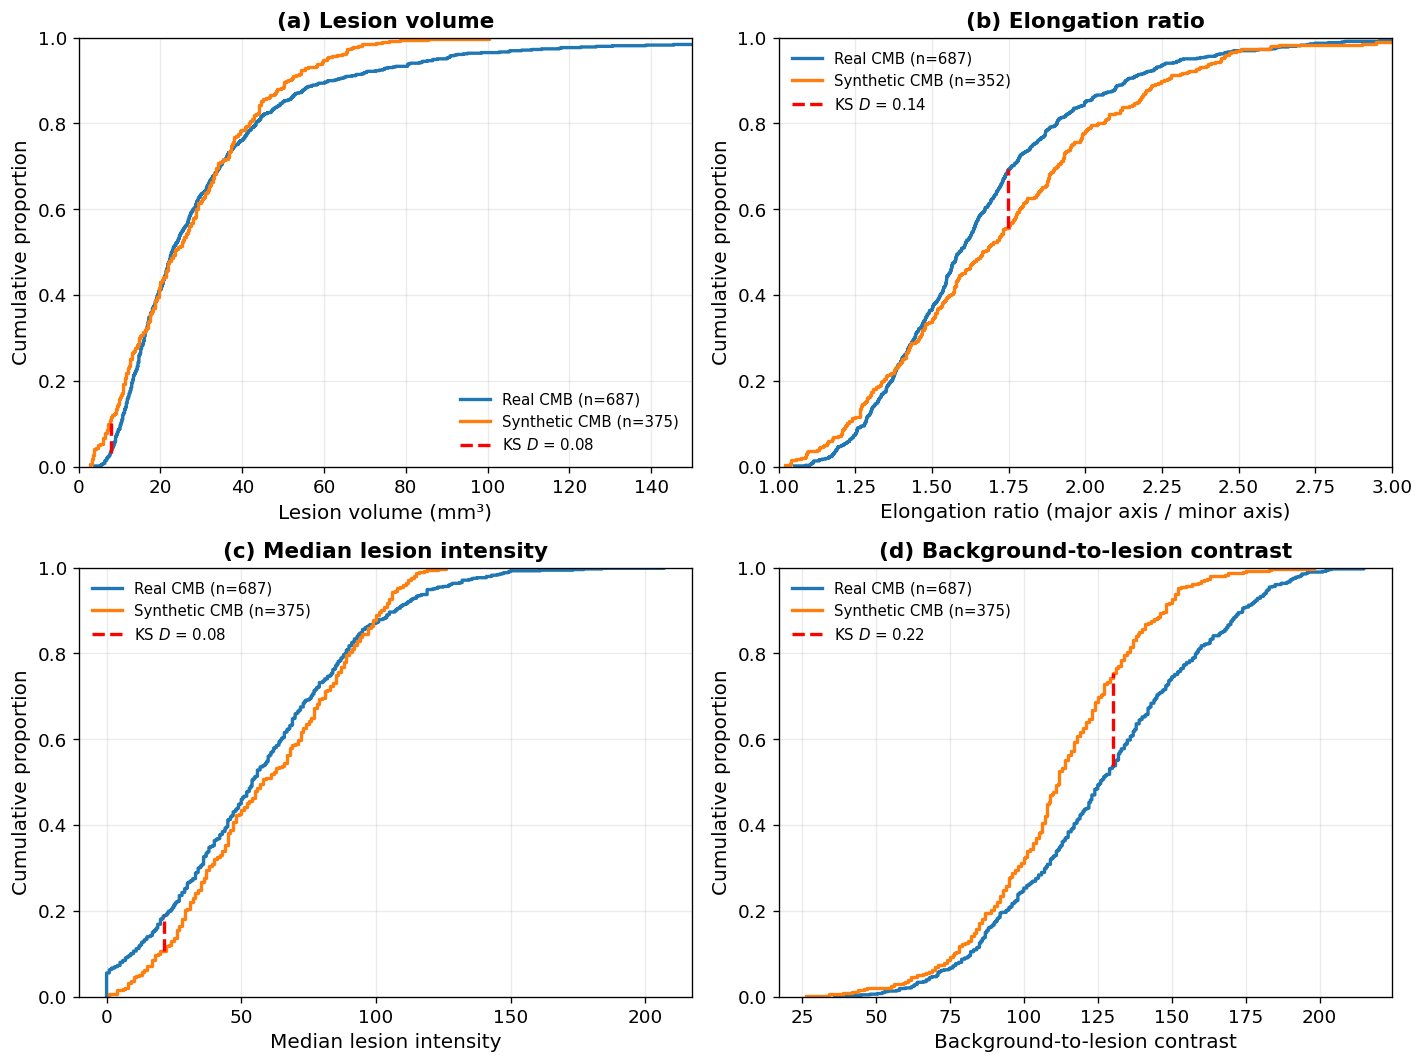

In [6]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import ks_2samp


# ================================================================
# Paths
# ================================================================

real_shape_csv = Path("./stats/Realmicrobleed_shape_stats.csv")
synth_shape_csv = Path("./stats/Synthmicrobleed_shape_stats.csv")

real_profile_csv = Path("./stats/Realmicrobleed_profile_stats.csv")
synth_profile_csv = Path("./stats/Synthmicrobleed_profile_stats.csv")

output_png = "./real_vs_synthetic_ecdf_composite.png"
output_pdf = "./real_vs_synthetic_ecdf_composite.pdf"


# ================================================================
# Load data
# ================================================================

real_shape = pd.read_csv(real_shape_csv)
synth_shape = pd.read_csv(synth_shape_csv)

real_profile = pd.read_csv(real_profile_csv)
synth_profile = pd.read_csv(synth_profile_csv)

for df in [real_shape, synth_shape, real_profile, synth_profile]:
    df.columns = df.columns.str.strip()


# ================================================================
# Helpers
# ================================================================

def clean_numeric(series):
    values = pd.to_numeric(series, errors="coerce")
    return values.replace([np.inf, -np.inf], np.nan).dropna()


def ecdf(data):
    x = np.sort(np.asarray(data, dtype=float))
    y = np.arange(1, len(x) + 1) / len(x)
    return x, y


def plot_ecdf_comparison(
    ax,
    real_values,
    synth_values,
    xlabel,
    title,
    xlim=None,
):
    real_values = np.asarray(real_values, dtype=float)
    synth_values = np.asarray(synth_values, dtype=float)

    real_values = real_values[np.isfinite(real_values)]
    synth_values = synth_values[np.isfinite(synth_values)]

    ks = ks_2samp(real_values, synth_values)

    real_x, real_y = ecdf(real_values)
    synth_x, synth_y = ecdf(synth_values)

    ax.step(
        real_x,
        real_y,
        where="post",
        linewidth=2,
        label=f"Real CMB (n={len(real_values)})",
    )

    ax.step(
        synth_x,
        synth_y,
        where="post",
        linewidth=2,
        label=f"Synthetic CMB (n={len(synth_values)})",
    )

    # Location of maximum KS difference
    x_ks = ks.statistic_location

    real_cdf_at_ks = np.mean(real_values <= x_ks)
    synth_cdf_at_ks = np.mean(synth_values <= x_ks)

    ax.vlines(
        x_ks,
        min(real_cdf_at_ks, synth_cdf_at_ks),
        max(real_cdf_at_ks, synth_cdf_at_ks),
        color="red",
        linestyles="--",
        linewidth=2,
        label=f"KS $D$ = {ks.statistic:.2f}",
    )

    ax.set_xlabel(xlabel)
    ax.set_ylabel("Cumulative proportion")
    ax.set_title(title, fontweight="bold")

    ax.set_ylim(0, 1)

    if xlim is not None:
        ax.set_xlim(*xlim)

    ax.grid(alpha=0.25)
    ax.legend(frameon=False, fontsize=9)

    return ks


# ================================================================
# Prepare full valid distributions
# ================================================================

# Lesion volume
real_volume = clean_numeric(real_shape["volume_mm3"])
synth_volume = clean_numeric(synth_shape["volume_mm3"])

real_volume = real_volume[real_volume > 0]
synth_volume = synth_volume[synth_volume > 0]


# Elongation
real_elongation = clean_numeric(
    real_shape["elongation_major_minor"]
)
synth_elongation = clean_numeric(
    synth_shape["elongation_major_minor"]
)

real_elongation = real_elongation[real_elongation >= 1.0]
synth_elongation = synth_elongation[synth_elongation >= 1.0]


# Median lesion intensity
real_intensity = clean_numeric(
    real_profile["lesion_intensity_median"]
)
synth_intensity = clean_numeric(
    synth_profile["lesion_intensity_median"]
)


# Background-to-lesion contrast
real_contrast = clean_numeric(
    real_profile["dark_contrast_abs_bg_minus_lesion"]
)
synth_contrast = clean_numeric(
    synth_profile["dark_contrast_abs_bg_minus_lesion"]
)


# ================================================================
# Composite ECDF figure
# ================================================================

fig, axes = plt.subplots(
    2,
    2,
    figsize=(12, 9),
)

plot_ecdf_comparison(
    axes[0, 0],
    real_volume,
    synth_volume,
    xlabel="Lesion volume (mm³)",
    title="(a) Lesion volume",
    xlim=(0, 150),
)

plot_ecdf_comparison(
    axes[0, 1],
    real_elongation,
    synth_elongation,
    xlabel="Elongation ratio (major axis / minor axis)",
    title="(b) Elongation ratio",
    xlim=(1.0, 3.0),
)

plot_ecdf_comparison(
    axes[1, 0],
    real_intensity,
    synth_intensity,
    xlabel="Median lesion intensity",
    title="(c) Median lesion intensity",
)

plot_ecdf_comparison(
    axes[1, 1],
    real_contrast,
    synth_contrast,
    xlabel="Background-to-lesion contrast",
    title="(d) Background-to-lesion contrast",
)

plt.tight_layout()

plt.savefig(
    output_png,
    dpi=300,
    bbox_inches="tight",
)

plt.savefig(
    output_pdf,
    bbox_inches="tight",
)

plt.show()